# RFM Analysis

RFM adalah metode yang digunakan untuk menganalisis nilai pelanggan. Padaumumnya digunakan dalam database marketing dan pemasaran langsung dan telah mendapat perhatian khusus dalam industri layanan ritel dan profesional.


RFM adalah singkatan dari tiga dimensi:

Recency– Seberapa baru pelanggan melakukan pembelian? \
Frequency – Seberapa sering mereka membeli? \
Monetary – Berapa banyak yang mereka habiskan? \

Sebelum memulai analisis RFM kita perlu menetapkan tujuan dan hasil analisis, untuk tujuan contoh ini adalah untuk menentukan kelas contoh pelanggan - Platinum, Gold dan Silver.

Pelanggan Platinum - penghasil pendapatan yang sering dan lebih banyak. \
Pelanggan gold - penghasil pendapatan yang sering tetapi lebih sedikit. \
pelanggan silver - penghasil pendapatan yang lebih jarang dan lebih sedikit. \

## 1. Load Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn .preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load Data
df= pd.read_csv("data_RFM.csv", encoding="ISO-8859-1")

In [ ]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


### Check Missing value

In [ ]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### Remove Missing value pada data yang tidak diketahui

In [ ]:
df.dropna(subset=['CustomerID'],how='all',inplace=True)

In [ ]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,406829.000000,406829.000000,406829.000000
mean,12.061303,3.460471,15287.690570
std,248.693370,69.315162,1713.600303
min,-80995.000000,0.000000,12346.000000
25%,2.000000,1.250000,13953.000000
50%,5.000000,1.950000,15152.000000
75%,12.000000,3.750000,16791.000000
max,80995.000000,38970.000000,18287.000000


Data yang digunakan untuk pengolahan selanjutnya haruslah data yang benar positif sehingga mencerminkan proses transaksi yang dilakukan.

## Filtering Data

filtering pada data dengan menghilangkan nilai minus/nol yang diinterpretasikan transaksi yang gagal pada Quantity sedangkan pada UnitPrice harusnya sama dengan nol (memungkinkan adanya diskon 100%) hingga lebih besar.

In [ ]:
df1= df[(df.Quantity > 0) & (df.UnitPrice >= 0)]
print(df1.describe())

            Quantity      UnitPrice     CustomerID
count  397924.000000  397924.000000  397924.000000
mean       13.021823       3.116174   15294.315171
std       180.420210      22.096788    1713.169877
min         1.000000       0.000000   12346.000000
25%         2.000000       1.250000   13969.000000
50%         6.000000       1.950000   15159.000000
75%        12.000000       3.750000   16795.000000
max     80995.000000    8142.750000   18287.000000


In [ ]:
df1.shape

(397924, 8)

### Salah satu hal yang perlu diketahui dalam eksplor data experiment ini ialah mengenai jumlah transaksi, banyaknya produk dan jumlah customer yang ada.

In [ ]:
#Melihat jumlah produk, jumlah transaksi, dan pelanggan
cust_x_prod = pd.DataFrame([{'products':len(df1['StockCode'].value_counts()),
'transactions': len(df1['InvoiceNo'].value_counts()),
'customers': len(df1['CustomerID'].value_counts()),}], 
columns = ['products', 'transactions', 'customers'], index = ['quantity'])
print(cust_x_prod)

          products  transactions  customers
quantity      3665         18536       4339


In [ ]:
#tanggal maksimum data
df1['InvoiceDate'].max()

'9/9/2011 9:52'

In [ ]:
df1.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,date
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France,2011-12-09
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France,2011-12-09
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France,2011-12-09
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France,2011-12-09
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France,2011-12-09


In [ ]:
#ambil data paling terakhir transaksi
import datetime as dt
now = dt.date(2011,12,9)

In [ ]:
df1['date'] = pd.DatetimeIndex(df1.InvoiceDate).date

In [ ]:
df1.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,date
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01


## RFM Analysis

RFM (Recency, Frequency, Monetary) adalah metode paling umum yang digunakan marketer dalam menganalisa tingkah laku pelanggan, efisiensi dana pembuatan iklan, hingga meningkatkan profit penjualan. Tujuan dari metode RFM Analysis pada kesempatan ini ialah untuk mengkategorikan pelanggan berdasarkan beberapa kriteria.

### **Recency**--> Seberapa banyak waktu berkunjung belakangan/baru-baru ini pelanggan untuk membeli (pembelian yang baru menunjukkan low-recency).

In [ ]:
#Group by berdasarkan customer terakhir membeli

recency_df = df1.groupby(['CustomerID'],as_index=False)['date'].max()
recency_df.columns = ['CustomerID','LastPurchaseDate']
recency_df.head()

,CustomerID,LastPurchaseDate
0,12346.0,2011-01-18
1,12347.0,2011-12-07
2,12348.0,2011-09-25
3,12349.0,2011-11-21
4,12350.0,2011-02-02


Customer ID 12346, terakhir melakukan pembelian di toko tanggal 18 Januari 2011

In [ ]:
#hitung seberapa sering dia membeli dengan mengacu pada tanggal terbaru dalam beberapa hari

recency_df['Recency'] = recency_df.LastPurchaseDate.apply(lambda x : (now - x).days)
recency_df.head()

,CustomerID,LastPurchaseDate,Recency
0,12346.0,2011-01-18,325
1,12347.0,2011-12-07,2
2,12348.0,2011-09-25,75
3,12349.0,2011-11-21,18
4,12350.0,2011-02-02,310


### **Frequency** -->Seberapa banyak/jumlah mereka melakukan pembelian (pembelian yang tinggi berarti high-frequency)

In [ ]:
#periksa frekuensi pelanggan berarti sudah berapa kali transaksi

frequency_df = df1.copy()
frequency_df.drop_duplicates(subset=['CustomerID','InvoiceNo'], keep="first", inplace=True) 
frequency_df = frequency_df.groupby('CustomerID',as_index=False)['InvoiceNo'].count()
frequency_df.columns = ['CustomerID','Frequency']
frequency_df.head()

,CustomerID,Frequency
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


### **Monetary** = Seberapa banyak uang yang mereka spend untuk membeli (spend yang tinggi berarti high monetary)

In [ ]:
df1['Total_cost'] = df1['UnitPrice'] * df1['Quantity']

In [ ]:
monetary_df=df1.groupby('CustomerID',as_index=False)['Total_cost'].sum()
monetary_df.columns = ['CustomerID','Monetary']
monetary_df.head()

,CustomerID,Monetary
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [ ]:
#combine first recency and frequency
rf = recency_df.merge(frequency_df,left_on='CustomerID',right_on='CustomerID')

#combibe rf frame with monetary values
rfm = rf.merge(monetary_df,left_on='CustomerID',right_on='CustomerID')
rfm.set_index('CustomerID',inplace=True)
rfm.head()

,LastPurchaseDate,Recency,Frequency,Monetary
CustomerID,,,,
12346.0,2011-01-18,325,1,77183.60
12347.0,2011-12-07,2,7,4310.00
12348.0,2011-09-25,75,4,1797.24
12349.0,2011-11-21,18,1,1757.55
12350.0,2011-02-02,310,1,334.40


In [ ]:
rfm.drop(columns=['LastPurchaseDate'],inplace=True)
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,18,1,1757.55
12350.0,310,1,334.40


**Recency** ditemukan dari perbedaan tanggal terbaru terhadap tanggal terakhir dalam data transaksi. hal ini menunjukkan range waktu yang disebut sebagai **recency**. **Recency** yang **tinggi** akan menjelaskan bahwa pembeli sudah lama sekali tidak bertransaksi dan sebaliknya. 

Sedangkan **Frequency** ditemukan dari perhitungan jumlah InvoiceNo, dimana setiap CustomerID dapat melakukan beberapa transaksi yang akan mengkalkulasikan InvoiceNo. 

Sementara **Monetary** merupakan jumlah pengeluaran uang oleh pelanggan dengan cara mengkalikan quantity terhadap price. Idealnya pelanggan terbaik itu mencerminkan nilai recency yang rendah tetapi nilai frequency dan monetary yang tinggi.

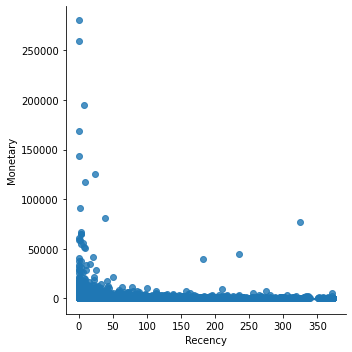

In [ ]:
# Monetary vs Recency for each segment
sns.lmplot(x='Recency', y='Monetary', data=rfm,fit_reg=True)

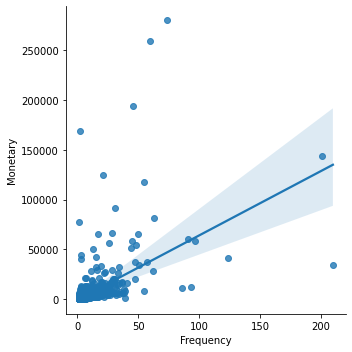

In [ ]:
sns.lmplot(x='Frequency', y='Monetary', data=rfm,fit_reg=True)

Dalam memastikan nilai rendah-tingginya score RFM, dilakukan beberapa perhitungan yang melihatkan klasifikasi berdasarkan quartiles dari data tersebut. pengunaan klasifikasi quartile merupakan cara simple dan pasti dalam menentukan limit dari setiap klasifikasinya. sebagai contoh, jika jumlah transaksi 100 kali dengan perhitungan quartile 25% (0,25) akan menunjukkan 4 kali periode waktu pembelian. semakin tinggi nilai pengkali quartile maka semakin kecil periode pembeliannya. hal yang sama juga berlaku untuk monetary dan berbanding terbalik terhadap perlakuan recency.

In [ ]:
quantiles = rfm.quantile(q=[0.25,0.5,0.75])
quantiles

,Recency,Frequency,Monetary,Cluster
0.25,17.0,1.0,307.245,1.0
0.50,50.0,2.0,674.450,1.0
0.75,141.5,5.0,1661.640,1.0


In [ ]:
RFMScores= rfm.copy()
#Recency Scoring
def Rscoring(x,p,d):
   if x <= d[p][0.25]:
      return 1
   elif x <= d[p][0.50]:
      return 2
   elif x <= d[p][0.75]:
      return 3
   else:
      return 4
#Frequency and Monetary Scoring
def FMscoring (x,p,d):
   if x <= d[p][0.25]:
      return 4
   elif x <= d[p][0.50]:
      return 3
   elif x <= d[p][0.75]:
      return 2
   else:
      return 1
RFMScores['R']=RFMScores['Recency'].apply(Rscoring, args=('Recency',quantiles))
RFMScores['F']=RFMScores['Frequency'].apply(FMscoring, args=('Frequency',quantiles))
RFMScores['M']=RFMScores['Monetary'].apply(FMscoring, args=('Monetary',quantiles))
RFMScores['RFMgroup']=RFMScores.R.map(str)+RFMScores.F.map(str)+RFMScores.M.map(str)
RFMScores['Score']=RFMScores[['R','F','M']].sum(axis=1)
print(RFMScores.head())

            Recency  Frequency  Monetary  Cluster  R  F  M RFMgroup  Score
CustomerID                                                                
12346.0         325          1  77183.60        0  4  4  1      441      9
12347.0           2          7   4310.00        1  1  1  1      111      3
12348.0          75          4   1797.24        1  3  2  1      321      6
12349.0          18          1   1757.55        1  2  4  1      241      7
12350.0         310          1    334.40        0  4  4  3      443     11


## Customer Segmentation menggunakan K-Means

**Kmeans** berperan dalam memisahkan data menjadi beberapa group sample data dengan variance yang sama. namun proses ini membutuhkan definisi jumlah clustering terlebih dahulu.

Sebelum melakukan proses clustering dengan Kmeans, ada baiknya kita memastikan data dalam kondisi yang ideal. pertama sekali memastikan bahwa data sudah terdistribusi dengan normal, hal tersebut dapat ditunjukkan dengan visualisasi histogram berikut ini.

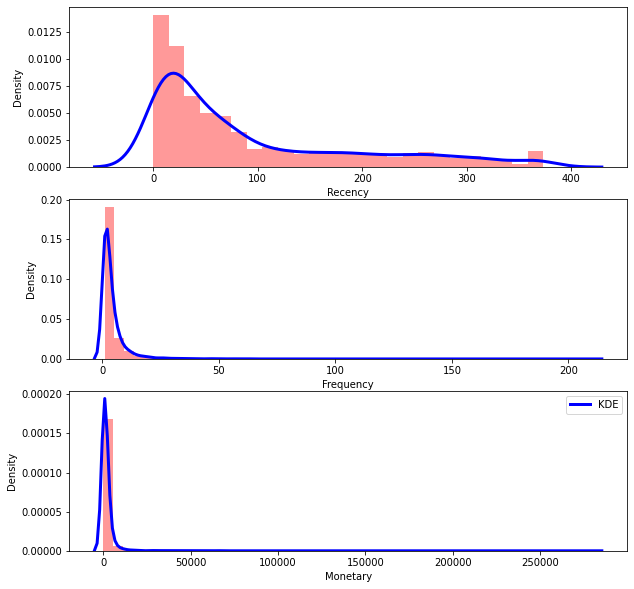

In [ ]:
#Melihat distibusi data hasil RFMScore
plt.figure(figsize=(10,10))
plt.subplot(3,1,1)
sns.distplot(rfm['Recency'],kde_kws={"color":"b","lw":3,"label":"KDE"},hist_kws={"color":"r"})
plt.subplot(3,1,2)
sns.distplot(rfm['Frequency'],kde_kws={"color":"b","lw":3,"label":"KDE"},hist_kws={"color":"r"})
plt.subplot(3,1,3)
sns.distplot(rfm['Monetary'],kde_kws={"color":"b","lw":3,"label":"KDE"},hist_kws={"color":"r"})
plt.legend()
plt.show()

Dengan melihat distribusi nilai diatas, menunjukkan persebaran data yang tidak seimbang dimana data mempunyai range yang jauh.  Pada praktik ini melakukan transformasi dengan mengunakan `MinMaxScaler`.

In [ ]:
clustering_rfm = rfm[['Recency',"Frequency","Monetary"]].copy()
clustering_rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,18,1,1757.55
12350.0,310,1,334.40


In [ ]:
min_max_scaler = MinMaxScaler()
x_scaled = min_max_scaler.fit_transform(clustering_fm)
data_scaled = pd.DataFrame(x_scaled,columns=['Recency','Frequency','Monetary'])
data_scaled

,Recency,Frequency,Monetary
0,0.871314,0.000000,0.275453
1,0.005362,0.028708,0.015382
2,0.201072,0.014354,0.006414
3,0.048257,0.000000,0.006272
4,0.831099,0.000000,0.001193
...,...,...,...
4334,0.742627,0.000000,0.000645
4335,0.482574,0.000000,0.000288
4336,0.018767,0.004785,0.000635
4337,0.008043,0.071770,0.007476


## Elbow Method

Text(0.5, 1.0, 'Elbow plot for optimal number of clusters')

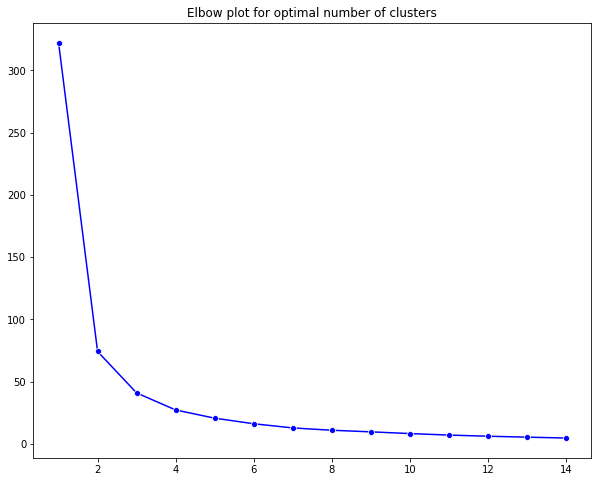

In [ ]:
wscc = []
for i in range(1,15): 
    kmeans = KMeans(n_clusters=i, init="k-means++",random_state=0)
    kmeans.fit(data_scaled)
    wscc.append(kmeans.inertia_)  

plt.figure(figsize=(10,8))
sns.lineplot(x=range(1,15),y=wscc,marker="o",c='blue')
plt.title("Elbow plot for optimal number of clusters")

In [ ]:
wscc

[322.20548394821503,
 74.13982079617115,
 40.853717761769076,
 27.177043158469303,
 20.58423947435832,
 16.094898259468156,
 12.745033981096402,
 10.876407944859366,
 9.594876347836674,
 8.215770723673726,
 7.002288113617173,
 6.077880113355891,
 5.335591665114627,
 4.622959454203285]

Penentuan jumlah clustering pada gambar disamping ini mengunakan sistem interpretatif personal dengan cara melihat titik yang memulai perbedaan tidak signifikan berubah atau nilai error yang tidak signifikan. Pada kasus ini jumlah clustering idealnya adalah 3 atau 4, dimana pada titik selanjutnya tidak menunjukkan perbedaan yang signifikan. langkah selanjutnya ialah melakukan clustering dengan jumlah cluster 3.

In [ ]:
#Clustering dengan mengunakan Kmeans.
kmeans = KMeans(n_clusters=3, random_state=0,init='k-means++',
                n_init =10,max_iter = 300).fit(data_scaled)
pred = kmeans.predict(data_scaled)
RFMScores['Cluster']=kmeans.labels_
RFMScores.head(10)

,Recency,Frequency,Monetary,Cluster,R,F,M,RFMgroup,Score
CustomerID,,,,,,,,,
12346.0,325,1,77183.60,0,4,4,1,441,9
12347.0,2,7,4310.00,1,1,1,1,111,3
12348.0,75,4,1797.24,1,3,2,1,321,6
12349.0,18,1,1757.55,1,2,4,1,241,7
12350.0,310,1,334.40,0,4,4,3,443,11
12352.0,36,8,2506.04,1,2,1,1,211,4
12353.0,204,1,89.00,2,4,4,4,444,12
12354.0,232,1,1079.40,0,4,4,2,442,10
12355.0,214,1,459.40,2,4,4,3,443,11


In [ ]:
RFMScores.groupby('Cluster').mean().sort_values('Score',ascending=False)

,Recency,Frequency,Monetary,R,F,M,Score
Cluster,,,,,,,
0,293.944089,1.354633,607.195479,4.000000,3.736422,3.388179,11.124601
2,152.321867,2.222359,796.941095,3.563882,3.074939,2.891892,9.530713
1,31.517420,5.477406,2719.073295,1.868230,2.341152,2.198344,6.407727


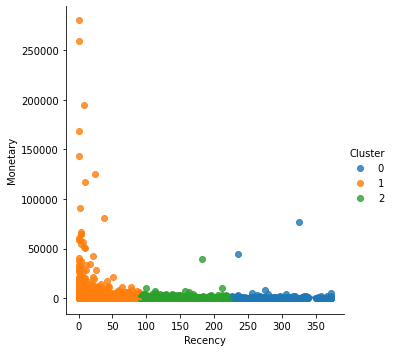

In [ ]:
sns.lmplot(x='Recency', y='Monetary', data=RFMScores, hue='Cluster', fit_reg=True)

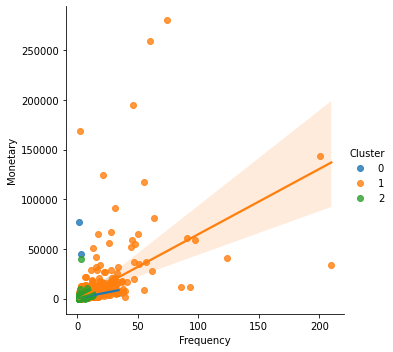

In [ ]:
sns.lmplot(x='Frequency', y='Monetary', data=RFMScores, hue='Cluster')

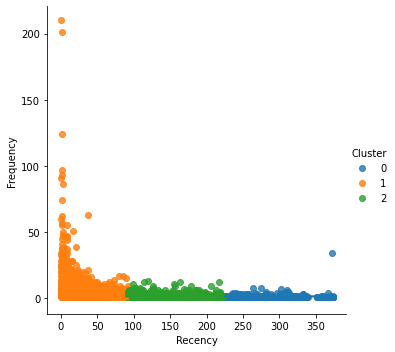

In [ ]:
sns.lmplot(x='Recency', y='Frequency', data=RFMScores, hue='Cluster', fit_reg=True)

Dari hasil analisis, diperoleh 3 cluster yaitu cluster 0, cluster 1, dan cluster 2. Jika dilihat, cluster 0 memiliki recency tinggi dengan frequency rendah dan monetary rendah. Artinya, pelanggan kelompok ini sudah lama dan jarang melakukan transaksi sehingga uang yang dikeluarkan pelanggan sedikit. Cluster 1 memiliki recency paling kecil dengan frequency dan monetary paling tinggi. Artinya, pelanggan kelompok ini masih sering dan paling sering melakukan transaksi sehingga uang yang dikeluarkan pelanggan sangat besar. Sedangkan cluster 2, memiliki recency, frequency dan monetary menangah diantara cluster 0 dan 1. Artinya, pelanggan kelompok ini pelanggan yang tidak jarang dan tidak sering pula melakukan transaksi dengan uang yang dikeluarkan tidak banyak dan tidak sedikit pula. Sehingga, dapat dikatakan cluster 0 adalah pelanggan silver, cluster 1 pelanggan platinum dan cluster 2 pelanggan gold.